In [21]:
import re
import numpy as np
import pandas as pd
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

In [22]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

Now we wiil use a sample text.

In [23]:
sample_text = """
Artificial intelligence has moved from research labs into everyday life at a
remarkable pace. Virtual assistants answer questions, recommendation systems
shape what we watch and buy, and language models can now draft essays and code.
This rapid progress has been driven largely by deep learning, a technique that
trains large neural networks on enormous amounts of data. However, these systems
also raise concerns. They can reflect biases present in their training data, and
their inner workings are often difficult to interpret. Researchers are actively
working on making models more transparent, fair, and reliable. Governments around
the world are also beginning to draft regulations to guide how AI is developed and
deployed. The coming decade will likely determine how these powerful tools reshape
work, education, and society as a whole.
"""

print(sample_text)


Artificial intelligence has moved from research labs into everyday life at a
remarkable pace. Virtual assistants answer questions, recommendation systems
shape what we watch and buy, and language models can now draft essays and code.
This rapid progress has been driven largely by deep learning, a technique that
trains large neural networks on enormous amounts of data. However, these systems
also raise concerns. They can reflect biases present in their training data, and
their inner workings are often difficult to interpret. Researchers are actively
working on making models more transparent, fair, and reliable. Governments around
the world are also beginning to draft regulations to guide how AI is developed and
deployed. The coming decade will likely determine how these powerful tools reshape
work, education, and society as a whole.



There are two ways of summarization.

**1. Extractive:** Most important sentences are selected and then they become stitched together. Nothing new is written.

**2. Abstractive:** a neural model rewrites the content in new words, like a human would. It reads more naturally but needs a large pretrained model

In [24]:
def summarize_extractive(text, num_sentences=3):
  # split the text into individual sentences.
  sentences = sent_tokenize(text)

  # if the text is too short then return it as it is.
  if len(sentences)<=num_sentences:
    return " ".join(sentences)

  # now convert each sentence to vector using TF-IDF vectorizer.
  vectorizer = TfidfVectorizer(stop_words='english')
  tfidf = vectorizer.fit_transform(sentences)

  # compute how similar a sentence is to every other sentences.
  similarity_matrix = cosine_similarity(tfidf)
  np.fill_diagonal(similarity_matrix,0)

  # build a graph and run PageRank to score sentence importance
  graph = nx.from_numpy_array(similarity_matrix)
  scores = nx.pagerank(graph,max_iter=500)

  # now it's time to pick the top scoring sentences.
  # after picking, put then in their original order.
  ranked = sorted(scores, key=scores.get, reverse=True)
  top_indices = sorted(ranked[:num_sentences])

  return " ".join(sentences[i] for i in top_indices)

In [25]:
extractive_summary = summarize_extractive(sample_text, num_sentences=3)
print("EXTRACTIVE SUMMARY:\n")
print(extractive_summary)

EXTRACTIVE SUMMARY:

Virtual assistants answer questions, recommendation systems
shape what we watch and buy, and language models can now draft essays and code. This rapid progress has been driven largely by deep learning, a technique that
trains large neural networks on enormous amounts of data. They can reflect biases present in their training data, and
their inner workings are often difficult to interpret.


In [26]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "sshleifer/distilbart-cnn-12-6"

# The tokenizer converts text <-> numbers the model understands.
tokenizer = AutoTokenizer.from_pretrained(model_name)

# AutoModelForSeq2SeqLM loads an encoder-decoder model — the right class
# for summarization (the input sequence is encoded, a new one is decoded).
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Use the GPU if enabled one, otherwise fall back to CPU automatically.
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("Model loaded on:", device)

Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

Model loaded on: cuda


In [27]:
def summarize_abstractive(text, max_length=200, min_length=50):
    # 1. Turn the text into token IDs the model can read.
    #    truncation=True safely trims anything past the model's 1024-token limit.
    inputs = tokenizer(
        text.strip(),
        max_length=1024,
        truncation=True,
        return_tensors="pt"    # return PyTorch tensors
    ).to(device)

    # 2. Generate the summary token IDs.
    summary_ids = model.generate(
        **inputs,
        max_length=max_length,       # longest the summary can be
        min_length=min_length,       # shortest it can be
        num_beams=4,                 # beam search: explores options for better quality
        length_penalty=2.0,          # gently discourages overly short output
        no_repeat_ngram_size=3,      # stops it repeating the same phrases
        early_stopping=True
    )

    # 3. Convert the generated token IDs back into readable text.
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True).strip()


abstractive_summary = summarize_abstractive(sample_text)
print("ABSTRACTIVE SUMMARY:\n")
print(abstractive_summary)

ABSTRACTIVE SUMMARY:

Artificial intelligence has moved from research labs into everyday life at a remarkable pace . Virtual assistants answer questions, recommendation systems shape what we watch and buy, and language models can now draft essays and code . The coming decade will likely determine how these powerful tools reshape society as a whole .


In [28]:
from rouge_score import rouge_scorer

def evaluate(summary, reference):
    # We ask for three ROUGE variants (explained below).
    scorer = rouge_scorer.RougeScorer(
        ["rouge1", "rouge2", "rougeL"], use_stemmer=True
    )
    scores = scorer.score(reference, summary)

    for metric, score in scores.items():
        print(f"{metric}: "
              f"precision={score.precision:.3f}, "
              f"recall={score.recall:.3f}, "
              f"f1={score.fmeasure:.3f}")

In [29]:
# A human-written summary of sample_text — your gold standard.
reference = ("AI has rapidly entered daily life through deep learning, but it "
             "raises concerns about bias and transparency, prompting research "
             "and regulation.")

print("EXTRACTIVE vs reference:")
evaluate(extractive_summary, reference)

print("\nABSTRACTIVE vs reference:")
evaluate(abstractive_summary, reference)

EXTRACTIVE vs reference:
rouge1: precision=0.082, recall=0.238, f1=0.122
rouge2: precision=0.017, recall=0.050, f1=0.025
rougeL: precision=0.066, recall=0.190, f1=0.098

ABSTRACTIVE vs reference:
rouge1: precision=0.100, recall=0.238, f1=0.141
rouge2: precision=0.000, recall=0.000, f1=0.000
rougeL: precision=0.080, recall=0.190, f1=0.113


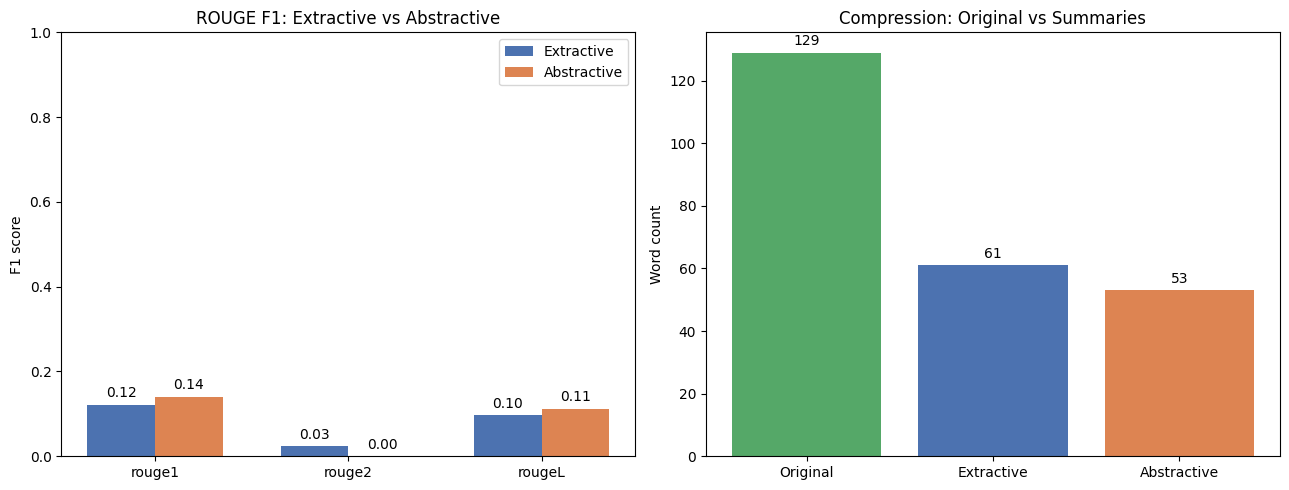

Saved chart to summarizer_results.png


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from rouge_score import rouge_scorer


def get_scores(summary, reference):
    """Return the ROUGE F1 score for each metric as a dict."""
    scorer = rouge_scorer.RougeScorer(
        ["rouge1", "rouge2", "rougeL"], use_stemmer=True
    )
    scores = scorer.score(reference, summary)
    return {metric: score.fmeasure for metric, score in scores.items()}


# compute scores for both methods
extractive_scores  = get_scores(extractive_summary, reference)
abstractive_scores = get_scores(abstractive_summary, reference)

metrics = ["rouge1", "rouge2", "rougeL"]
extractive_vals  = [extractive_scores[m]  for m in metrics]
abstractive_vals = [abstractive_scores[m] for m in metrics]

# set up a figure with two side-by-side charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# shart 1: ROUGE F1 comparison (grouped bars)
x = np.arange(len(metrics))
width = 0.35

bars1 = ax1.bar(x - width/2, extractive_vals,  width,
                label="Extractive",  color="#4C72B0")
bars2 = ax1.bar(x + width/2, abstractive_vals, width,
                label="Abstractive", color="#DD8452")

ax1.set_ylabel("F1 score")
ax1.set_title("ROUGE F1: Extractive vs Abstractive")
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1)
ax1.legend()
ax1.bar_label(bars1, fmt="%.2f", padding=3)
ax1.bar_label(bars2, fmt="%.2f", padding=3)

# chart 2: Compression (word counts)
lengths = {
    "Original":    len(sample_text.split()),
    "Extractive":  len(extractive_summary.split()),
    "Abstractive": len(abstractive_summary.split()),
}
bars3 = ax2.bar(lengths.keys(), lengths.values(),
                color=["#55A868", "#4C72B0", "#DD8452"])
ax2.set_ylabel("Word count")
ax2.set_title("Compression: Original vs Summaries")
ax2.bar_label(bars3, padding=3)

plt.tight_layout()
plt.savefig("summarizer_results.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved chart to summarizer_results.png")